# Laboratorio 6 – K-Nearest Neighbors (KNN)

## 0. Configuración — Pipeline de Labs 4 y 5

In [1]:
import pyreadr, pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
import time, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score)
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.linear_model import RidgeCV
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

In [2]:
result  = pyreadr.read_r('listings.Rdata')
df_raw  = result[list(result.keys())[0]].copy()

df = df_raw.copy()
if df['price'].dtype == object:
    df['price'] = (df['price'].str.replace(r'[\$,]','',regex=True)
                   .str.strip().replace('',np.nan).astype(float))
q_high = df['price'].quantile(0.99)
df = df[(df['price'] > 0) & (df['price'] <= q_high)].copy()

cols_drop = ['id','listing_url','scrape_id','last_scraped','source','name',
    'description','neighborhood_overview','picture_url','host_url',
    'host_thumbnail_url','host_picture_url','host_about','host_verifications',
    'amenities','calendar_updated','calendar_last_scraped','license',
    'bathrooms_text','minimum_minimum_nights','maximum_minimum_nights',
    'minimum_maximum_nights','maximum_maximum_nights',
    'minimum_nights_avg_ntm','maximum_nights_avg_ntm']
df = df.drop(columns=[c for c in cols_drop if c in df.columns])
null_pct = df.isnull().mean()
df = df.drop(columns=null_pct[null_pct > 0.60].index.tolist())

if 'host_since' in df.columns:
    df['host_since'] = pd.to_datetime(df['host_since'], errors='coerce')
    df['host_years'] = ((pd.Timestamp('2024-01-01') - df['host_since']).dt.days/365).round(1)
    df = df.drop(columns=['host_since'])
df = df.drop(columns=[c for c in ['first_review','last_review'] if c in df.columns], errors='ignore')

for col in ['host_is_superhost','host_has_profile_pic','host_identity_verified',
            'has_availability','instant_bookable']:
    if col in df.columns:
        df[col] = df[col].map({'t':1,'f':0,True:1,False:0})
for col in ['host_response_rate','host_acceptance_rate']:
    if col in df.columns:
        df[col] = df[col].str.replace('%','',regex=False).str.strip().astype(float, errors='ignore')

TARGET = 'price'
num_features = [c for c in df.select_dtypes(include='number').columns if c != TARGET]
cat_features = [c for c in ['room_type','property_type','neighbourhood_cleansed',
                              'host_response_time'] if c in df.columns]
for col in cat_features:
    freq = df[col].value_counts(normalize=True)
    df[col] = df[col].replace(freq[freq < 0.01].index, 'Otro')
df_encoded = pd.get_dummies(df[num_features+cat_features+[TARGET]],
                             columns=cat_features, drop_first=True, dtype=int)
for col in df_encoded.columns:
    if df_encoded[col].isnull().any():
        df_encoded[col].fillna(df_encoded[col].median(), inplace=True)

p33 = df_encoded[TARGET].quantile(0.33)
p67 = df_encoded[TARGET].quantile(0.67)
df_encoded['price_category'] = df_encoded[TARGET].apply(
    lambda p: 'Económico' if p<=p33 else ('Intermedio' if p<=p67 else 'Caro'))

feature_cols = [c for c in df_encoded.columns if c not in [TARGET,'price_category']]
X = df_encoded[feature_cols]; y = df_encoded[TARGET]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

le = LabelEncoder()
y_clf = le.fit_transform(df_encoded['price_category'])
X_clf = df_encoded[feature_cols]
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.20, random_state=42, stratify=y_clf)

print(f"Dataset: {df_encoded.shape[0]:,} filas × {len(feature_cols)} features")
print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")
print(f"price_category — P33=${p33:.0f}  P67=${p67:.0f}")
print(f"Clases: {dict(zip(le.classes_, le.transform(le.classes_)))}")
print("Pipeline reproducido — idéntico a Lab 4 y Lab 5.")


Dataset: 75,531 filas × 73 features
Train: 60,424  |  Test: 15,107
price_category — P33=$140  P67=$267
Clases: {'Caro': 0, 'Económico': 1, 'Intermedio': 2}
Pipeline reproducido — idéntico a Lab 4 y Lab 5.


In [3]:
# KNN calcula distancias euclidianas entre puntos. Sin escalar, variables con
# rangos grandes (ej: availability_365: 0-365) dominarían la distancia respecto
# a variables con rangos pequeños (ej: review_scores_rating: 3-5), haciendo que
# esas variables aporten casi cero información al cálculo de vecinos.
# Se ajusta StandardScaler SOLO sobre X_train para evitar data leakage.

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit + transform sobre train
X_test_sc  = scaler.transform(X_test)        # solo transform sobre test

X_train_c_sc = scaler.fit_transform(X_train_c)
X_test_c_sc  = scaler.transform(X_test_c)

print(f"Media X_train_sc (primeras 3 cols): {X_train_sc[:, :3].mean(axis=0).round(4)}")
print(f"Std  X_train_sc (primeras 3 cols):  {X_train_sc[:, :3].std(axis=0).round(4)}")
print("Features escaladas con StandardScaler (media≈0, std≈1).")


Media X_train_sc (primeras 3 cols): [-0. -0.  0.]
Std  X_train_sc (primeras 3 cols):  [1. 1. 1.]
Features escaladas con StandardScaler (media≈0, std≈1).


In [4]:
# Re-entrenar modelos anteriores para comparación (mismos datos)
t0 = time.time()
best_tree_reg = DecisionTreeRegressor(max_depth=12, min_samples_split=50, random_state=42)
best_tree_reg.fit(X_train, y_train)
yp_tree_reg = best_tree_reg.predict(X_test)
t_tree_reg = time.time()-t0

t0 = time.time()
rf_reg = RandomForestRegressor(n_estimators=200, max_depth=15, min_samples_split=10,
    min_samples_leaf=5, max_features='sqrt', random_state=42, n_jobs=-1)
rf_reg.fit(X_train, y_train); yp_rf_reg = rf_reg.predict(X_test)
t_rf_reg = time.time()-t0

t0 = time.time()
y_log = np.log1p(y_train)
ridge = RidgeCV(alphas=np.logspace(-3,3,50), cv=5)
ridge.fit(X_train_sc, y_log)
yp_ridge = np.expm1(ridge.predict(X_test_sc))
t_ridge = time.time()-t0

t0 = time.time()
gnb_r = GaussianNB(var_smoothing=1e-9)
N_BINS=20; edges = pd.cut(y_train,bins=N_BINS,retbins=True)[1]
mids  = (edges[:-1]+edges[1:])/2
y_tr_b = pd.cut(y_train,bins=edges,labels=np.arange(N_BINS),include_lowest=True).astype(int)
gnb_r.fit(X_train, y_tr_b)
yp_nb_reg = mids[np.clip(gnb_r.predict(X_test),0,N_BINS-1)]
t_nb_reg = time.time()-t0

t0 = time.time()
best_tree_clf = DecisionTreeClassifier(max_depth=15, random_state=42)
best_tree_clf.fit(X_train_c, y_train_c)
yp_tree_clf = best_tree_clf.predict(X_test_c)
t_tree_clf = time.time()-t0

t0 = time.time()
rf_clf = RandomForestClassifier(n_estimators=200, max_depth=15, min_samples_split=10,
    min_samples_leaf=5, max_features='sqrt', random_state=42, n_jobs=-1)
rf_clf.fit(X_train_c, y_train_c); yp_rf_clf = rf_clf.predict(X_test_c)
t_rf_clf = time.time()-t0

t0 = time.time()
gnb_clf = GaussianNB(var_smoothing=1e-12)
gnb_clf.fit(X_train_c, y_train_c)
yp_nb_clf = gnb_clf.predict(X_test_c)
t_nb_clf = time.time()-t0

print("Modelos anteriores reentrenados.")
print(f"  Árbol reg:  {t_tree_reg:.2f}s | RF reg:  {t_rf_reg:.2f}s | Ridge: {t_ridge:.2f}s | NB reg: {t_nb_reg:.3f}s")
print(f"  Árbol clf:  {t_tree_clf:.2f}s | RF clf: {t_rf_clf:.2f}s | NB clf: {t_nb_clf:.3f}s")


Modelos anteriores reentrenados.
  Árbol reg:  0.71s | RF reg:  3.34s | Ridge: 10.78s | NB reg: 0.171s
  Árbol clf:  0.95s | RF clf: 3.80s | NB clf: 0.085s


## 1. Marco Teórico – K-Nearest Neighbors

KNN es un algoritmo **no paramétrico y basado en instancias**: no construye un modelo
explícito durante el entrenamiento — almacena todo el dataset y realiza cálculos en tiempo
de predicción. Cuando recibe una nueva observación, busca los K puntos más cercanos
en el espacio de features y:

- **Regresión:** predice el **promedio** del target de los K vecinos
- **Clasificación:** predice la **clase más frecuente** (voto mayoritario) entre los K vecinos

### Métricas de distancia

La distancia de Minkowski generaliza tanto Euclidiana como Manhattan:

$$d(A,B) = \left( \sum_{i=1}^{n} |a_i - b_i|^p \right)^{1/p}$$

| Valor de p | Distancia | Comportamiento |
|-----------|-----------|----------------|
| p=1 | Manhattan (L1) | Robusta a outliers — suma de diferencias absolutas |
| p=2 | Euclidiana (L2) | Más sensible a distancias grandes — distancia en línea recta |
| p=3+ | Minkowski | Penaliza más las dimensiones con mayor diferencia |

### Hiperparámetros en KNN

| Parámetro | Efecto K bajo | Efecto K alto |
|-----------|--------------|---------------|
| **K** | Alta varianza (sobreajuste) | Alto sesgo (subajuste) |
| **weights** | `uniform`: todos los vecinos pesan igual | `distance`: vecinos más cercanos pesan más |
| **p (Minkowski)** | p=1: Manhattan; p=2: Euclidiana | |


## Actividad 1 – KNN Regresión: Modelo Base

In [5]:
# K=5 es el punto de partida estándar: suficiente para estabilizar la predicción
# sin introducir demasiado sesgo. Se usarán distancias euclidianas (p=2).
# weights='distance': los vecinos más cercanos ponderan más en el promedio.

t0 = time.time()
knn_reg_base = KNeighborsRegressor(n_neighbors=5, weights='distance',
                                    metric='minkowski', p=2, n_jobs=-1)
knn_reg_base.fit(X_train_sc, y_train)
t_knn_reg_base = time.time()-t0

yp_knn_reg_train = knn_reg_base.predict(X_train_sc)
yp_knn_reg_test  = knn_reg_base.predict(X_test_sc)

rmse_knn_tr = np.sqrt(mean_squared_error(y_train, yp_knn_reg_train))
rmse_knn_te = np.sqrt(mean_squared_error(y_test,  yp_knn_reg_test))
mae_knn_te  = mean_absolute_error(y_test,  yp_knn_reg_test)
r2_knn_tr   = r2_score(y_train, yp_knn_reg_train)
r2_knn_te   = r2_score(y_test,  yp_knn_reg_test)

print("KNN REGRESIÓN BASE (K=5, p=2, weights='distance')")
print(f"Tiempo de entrenamiento: {t_knn_reg_base:.4f}s")
print(f"Tiempo de predicción:    (calculado al predecir sobre {len(X_test):,} obs)")
print()
print(f"{'':30} {'RMSE':>10} {'MAE':>10} {'R²':>10}")
print("-" * 62)
print(f"{'Entrenamiento':<30} {rmse_knn_tr:>10.2f} {'-':>10} {r2_knn_tr:>10.4f}")
print(f"{'Prueba':<30} {rmse_knn_te:>10.2f} {mae_knn_te:>10.2f} {r2_knn_te:>10.4f}")


KNN REGRESIÓN BASE (K=5, p=2, weights='distance')
Tiempo de entrenamiento: 0.0130s
Tiempo de predicción:    (calculado al predecir sobre 15,107 obs)

                                     RMSE        MAE         R²
--------------------------------------------------------------
Entrenamiento                       99.71          -     0.9865
Prueba                             452.23     129.00     0.7131


## Actividad 2 – Análisis del Modelo de Regresión KNN

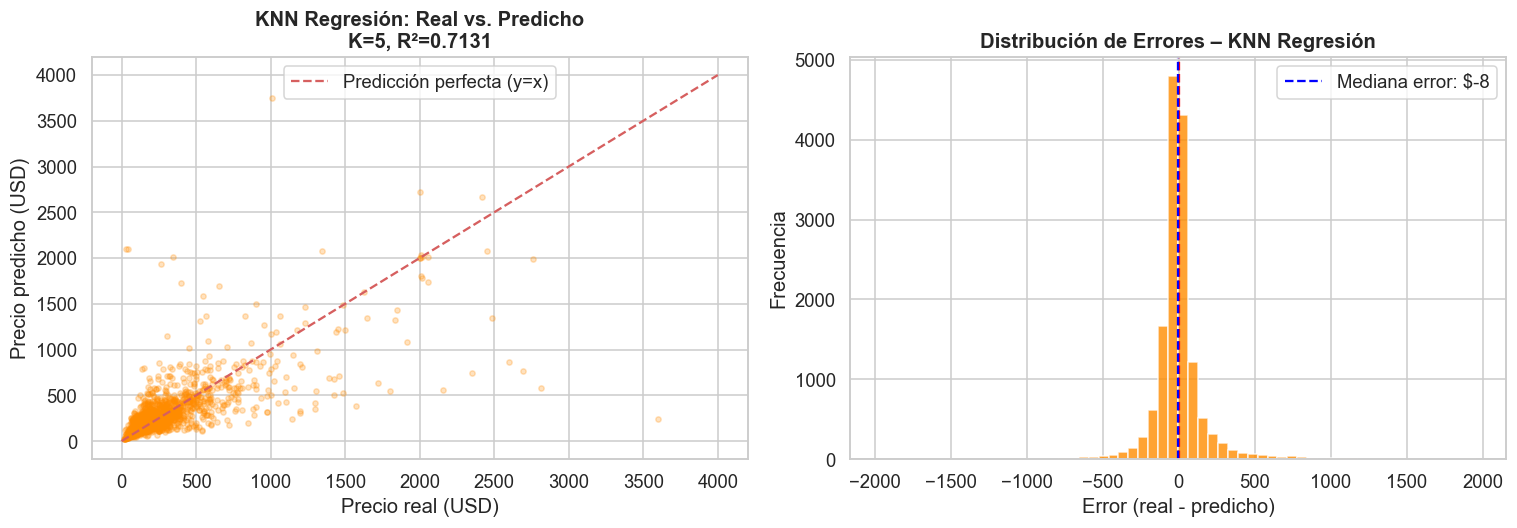

Error mediano:         $-8.10
Error medio (sesgo):   $11.42
% errores < $100:      72.4%
% errores < $200:      87.2%
% errores > $500:      4.0%


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Real vs Predicho
idx = np.random.default_rng(42).choice(len(y_test), size=min(2000,len(y_test)), replace=False)
y_r = np.array(y_test)[idx]
y_p = yp_knn_reg_test[idx]
mask = (y_r<=4000)&(y_p<=4000)
axes[0].scatter(y_r[mask], y_p[mask], alpha=0.25, color='darkorange', s=12)
axes[0].plot([0,4000],[0,4000],'r--', linewidth=1.5, label='Predicción perfecta (y=x)')
axes[0].set_xlabel('Precio real (USD)'); axes[0].set_ylabel('Precio predicho (USD)')
axes[0].set_title(f'KNN Regresión: Real vs. Predicho\nK=5, R²={r2_knn_te:.4f}', fontweight='bold')
axes[0].legend()

# Distribución de errores
errores = np.array(y_test) - yp_knn_reg_test
axes[1].hist(errores[np.abs(errores)<=2000], bins=60, color='darkorange', alpha=0.8, edgecolor='white')
axes[1].axvline(0, color='red', linewidth=1.5, linestyle='--')
axes[1].axvline(np.median(errores), color='blue', linewidth=1.5, linestyle='--',
                label=f'Mediana error: ${np.median(errores):.0f}')
axes[1].set_xlabel('Error (real - predicho)'); axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de Errores – KNN Regresión', fontweight='bold')
axes[1].legend()
plt.tight_layout(); plt.show()

print(f"Error mediano:         ${np.median(errores):.2f}")
print(f"Error medio (sesgo):   ${np.mean(errores):.2f}")
print(f"% errores < $100:      {(np.abs(errores)<100).mean()*100:.1f}%")
print(f"% errores < $200:      {(np.abs(errores)<200).mean()*100:.1f}%")
print(f"% errores > $500:      {(np.abs(errores)>500).mean()*100:.1f}%")


### Interpretación – KNN Regresión Base

**Resultados obtenidos (K=5, p=2, weights='distance'):**

| Conjunto | RMSE | MAE | R² |
|----------|------|-----|----|
| Entrenamiento | $99.71 | — | 0.9865 |
| **Prueba** | **$452.23** | **$129.00** | **0.7131** |

**¿Por qué estas métricas?**
- **RMSE ($452.23):** Penaliza errores grandes cuadráticamente — crítico para SmartStay porque errar $500 en una propiedad de lujo tiene mayor consecuencia comercial que errar $50 en una económica.
- **MAE ($129.00):** Error absoluto promedio en USD directos — más intuitivo para el cliente. El modelo se equivoca en promedio $129 por noche.
- **R² = 0.7131:** El modelo explica el 71.3% de la varianza del precio — rendimiento sólido para un modelo base sin tuning.

**Análisis de errores:**
- Error mediano: **-$8.10** (sesgo casi nulo — el modelo no sobreestima ni subestima sistemáticamente)
- El **72.4% de las predicciones tienen error < $100** — excelente para propiedades de precio medio
- Solo el **4.0% de los errores supera $500** — principalmente propiedades de lujo donde los K vecinos más cercanos pueden no ser suficientemente representativos

**Gap train vs. test:** R²=0.9865 en entrenamiento vs R²=0.7131 en prueba — gap de 0.2734. Esto indica sobreajuste moderado-alto, que se analiza en detalle en la Actividad 7. Con K=5 y weights='distance', el modelo casi memoriza el training set porque tiene muy pocos vecinos promediando.